# Explore Average Shower Data

This notebook loads cached shower data generated by the diffusion model pipeline and explores:
- Primary particle parameter distributions (energy, zenith, azimuth)
- Bounding box statistics
- Individual and average shower visualizations
- Energy- and angle-binned average showers
- Pixel-wise statistics and channel correlations

**Important:** All mean/std computations are performed *after* resampling each
shower onto a common physical coordinate grid using its bounding box, so that
showers with different spatial extents are properly aligned before averaging.

## 1. Imports & Data Loading

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ── Load cached showers ──────────────────────────────────────────────
cache_path = (
    "/n/home05/zdimitrov/tambo/TambOpt/detector_optimization_v2/"
    "outputs/NN_Files_28_20k_less_detectors_caching tests/"
    # "cached_showers_20000.pt"
    "cached_showers_500.pt"
)

shower_rgb, bboxes, p_energy, sin_z, cos_z, sin_a, cos_a = torch.load(
    cache_path, map_location="cpu"
)

print("=== Cached Shower Data ===")
print(f"shower_rgb : {shower_rgb.shape}  dtype={shower_rgb.dtype}")
print(f"bboxes     : {bboxes.shape}  dtype={bboxes.dtype}")
print(f"p_energy   : {p_energy.shape}  dtype={p_energy.dtype}")
print(f"sin_z      : {sin_z.shape}  dtype={sin_z.dtype}")
print(f"cos_z      : {cos_z.shape}  dtype={cos_z.dtype}")
print(f"sin_a      : {sin_a.shape}  dtype={sin_a.dtype}")
print(f"cos_a      : {cos_a.shape}  dtype={cos_a.dtype}")

# ── Derived quantities ────────────────────────────────────────────────
zenith  = torch.atan2(sin_z, cos_z)          # radians
azimuth = torch.atan2(sin_a, cos_a)           # radians

# Combined density x energy product (channels 0 and 1)
density_energy = torch.prod(shower_rgb[:, :, :, :2], dim=3)  # (B, 32, 32)

# Bounding-box widths / heights
bbox_width  = bboxes[:, 1] - bboxes[:, 0]    # x extent [m]
bbox_height = bboxes[:, 3] - bboxes[:, 2]    # y extent [m]
bbox_cx     = (bboxes[:, 0] + bboxes[:, 1]) / 2
bbox_cy     = (bboxes[:, 2] + bboxes[:, 3]) / 2

N = shower_rgb.shape[0]
print(f"\nTotal showers loaded: {N}")
print(f"Energy range: [{p_energy.min():.4e}, {p_energy.max():.4e}]")
print(f"Zenith range: [{zenith.min():.3f}, {zenith.max():.3f}] rad")
print(f"Azimuth range: [{azimuth.min():.3f}, {azimuth.max():.3f}] rad")

=== Cached Shower Data ===
shower_rgb : torch.Size([500, 32, 32, 3])  dtype=torch.float32
bboxes     : torch.Size([500, 4])  dtype=torch.float32
p_energy   : torch.Size([500])  dtype=torch.float32
sin_z      : torch.Size([500])  dtype=torch.float32
cos_z      : torch.Size([500])  dtype=torch.float32
sin_a      : torch.Size([500])  dtype=torch.float32
cos_a      : torch.Size([500])  dtype=torch.float32

Total showers loaded: 500
Energy range: [1.0006e-05, 9.7883e-01]
Zenith range: [0.014, 3.139] rad
Azimuth range: [-3.133, 3.140] rad


## 2. Primary Parameter Distributions

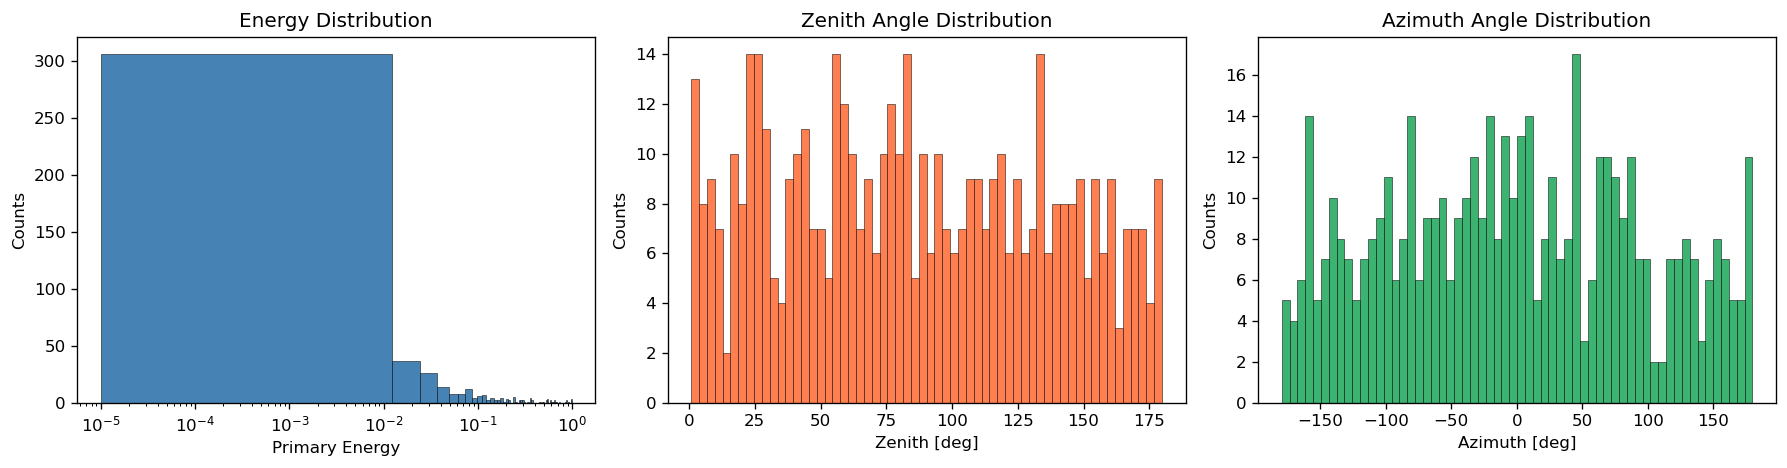

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Energy (log scale)
axes[0].hist(p_energy.numpy(), bins=80, color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].set_xscale('log')
axes[0].set_xlabel('Primary Energy')
axes[0].set_ylabel('Counts')
axes[0].set_title('Energy Distribution')

# Zenith
axes[1].hist(np.degrees(zenith.numpy()), bins=60, color='coral', edgecolor='k', linewidth=0.3)
axes[1].set_xlabel('Zenith [deg]')
axes[1].set_ylabel('Counts')
axes[1].set_title('Zenith Angle Distribution')

# Azimuth
axes[2].hist(np.degrees(azimuth.numpy()), bins=60, color='mediumseagreen', edgecolor='k', linewidth=0.3)
axes[2].set_xlabel('Azimuth [deg]')
axes[2].set_ylabel('Counts')
axes[2].set_title('Azimuth Angle Distribution')

plt.tight_layout()
plt.show()

## 3. Bounding Box Analysis

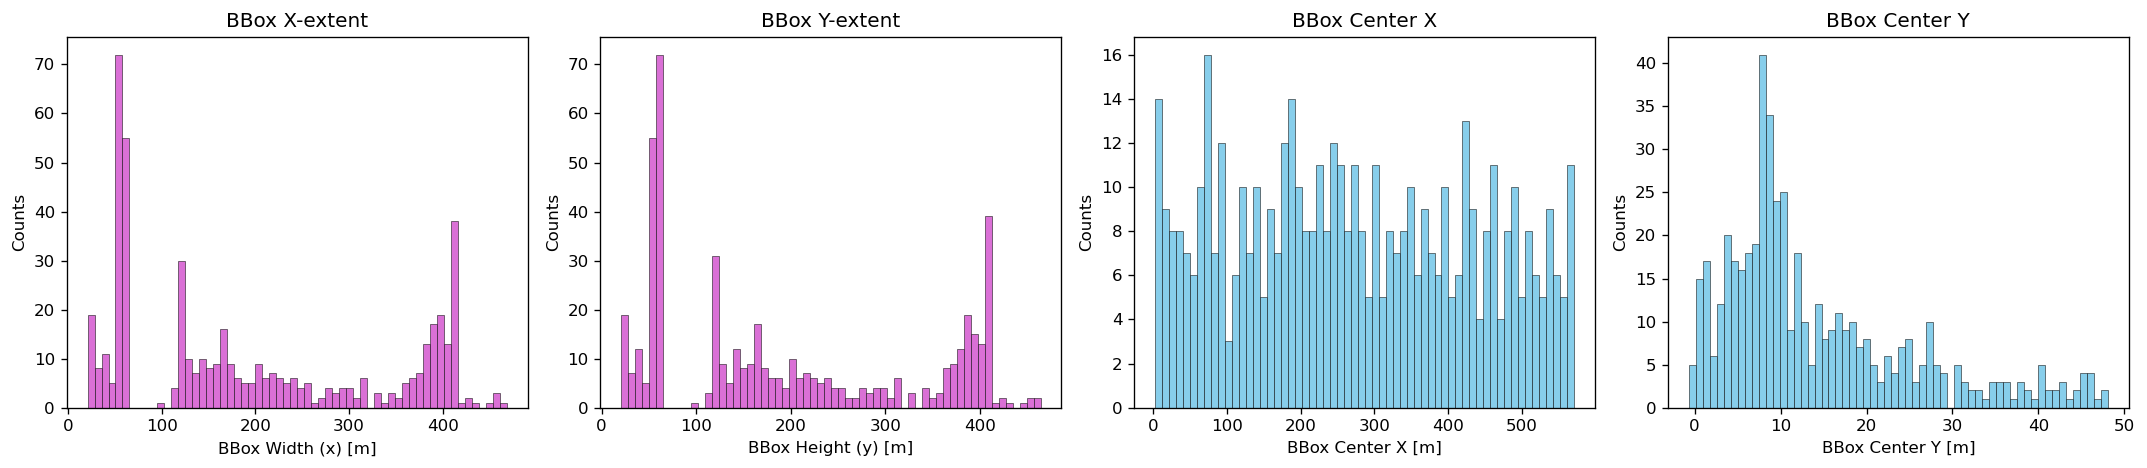

BBox width  -- mean: 197.6 m, std: 139.8 m
BBox height -- mean: 196.4 m, std: 138.2 m
BBox center X -- mean: 273.0 m, range: [2.3, 571.4]
BBox center Y -- mean: 14.1 m, range: [-0.7, 48.1]


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(bbox_width.numpy(), bins=60, color='orchid', edgecolor='k', linewidth=0.3)
axes[0].set_xlabel('BBox Width (x) [m]')
axes[0].set_title('BBox X-extent')

axes[1].hist(bbox_height.numpy(), bins=60, color='orchid', edgecolor='k', linewidth=0.3)
axes[1].set_xlabel('BBox Height (y) [m]')
axes[1].set_title('BBox Y-extent')

axes[2].hist(bbox_cx.numpy(), bins=60, color='skyblue', edgecolor='k', linewidth=0.3)
axes[2].set_xlabel('BBox Center X [m]')
axes[2].set_title('BBox Center X')

axes[3].hist(bbox_cy.numpy(), bins=60, color='skyblue', edgecolor='k', linewidth=0.3)
axes[3].set_xlabel('BBox Center Y [m]')
axes[3].set_title('BBox Center Y')

for ax in axes:
    ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

# Summary stats
print(f"BBox width  -- mean: {bbox_width.mean():.1f} m, std: {bbox_width.std():.1f} m")
print(f"BBox height -- mean: {bbox_height.mean():.1f} m, std: {bbox_height.std():.1f} m")
print(f"BBox center X -- mean: {bbox_cx.mean():.1f} m, range: [{bbox_cx.min():.1f}, {bbox_cx.max():.1f}]")
print(f"BBox center Y -- mean: {bbox_cy.mean():.1f} m, range: [{bbox_cy.min():.1f}, {bbox_cy.max():.1f}]")

## 4. Individual Shower Visualization

Show a selection of showers with all 3 channels + the combined density x energy product.

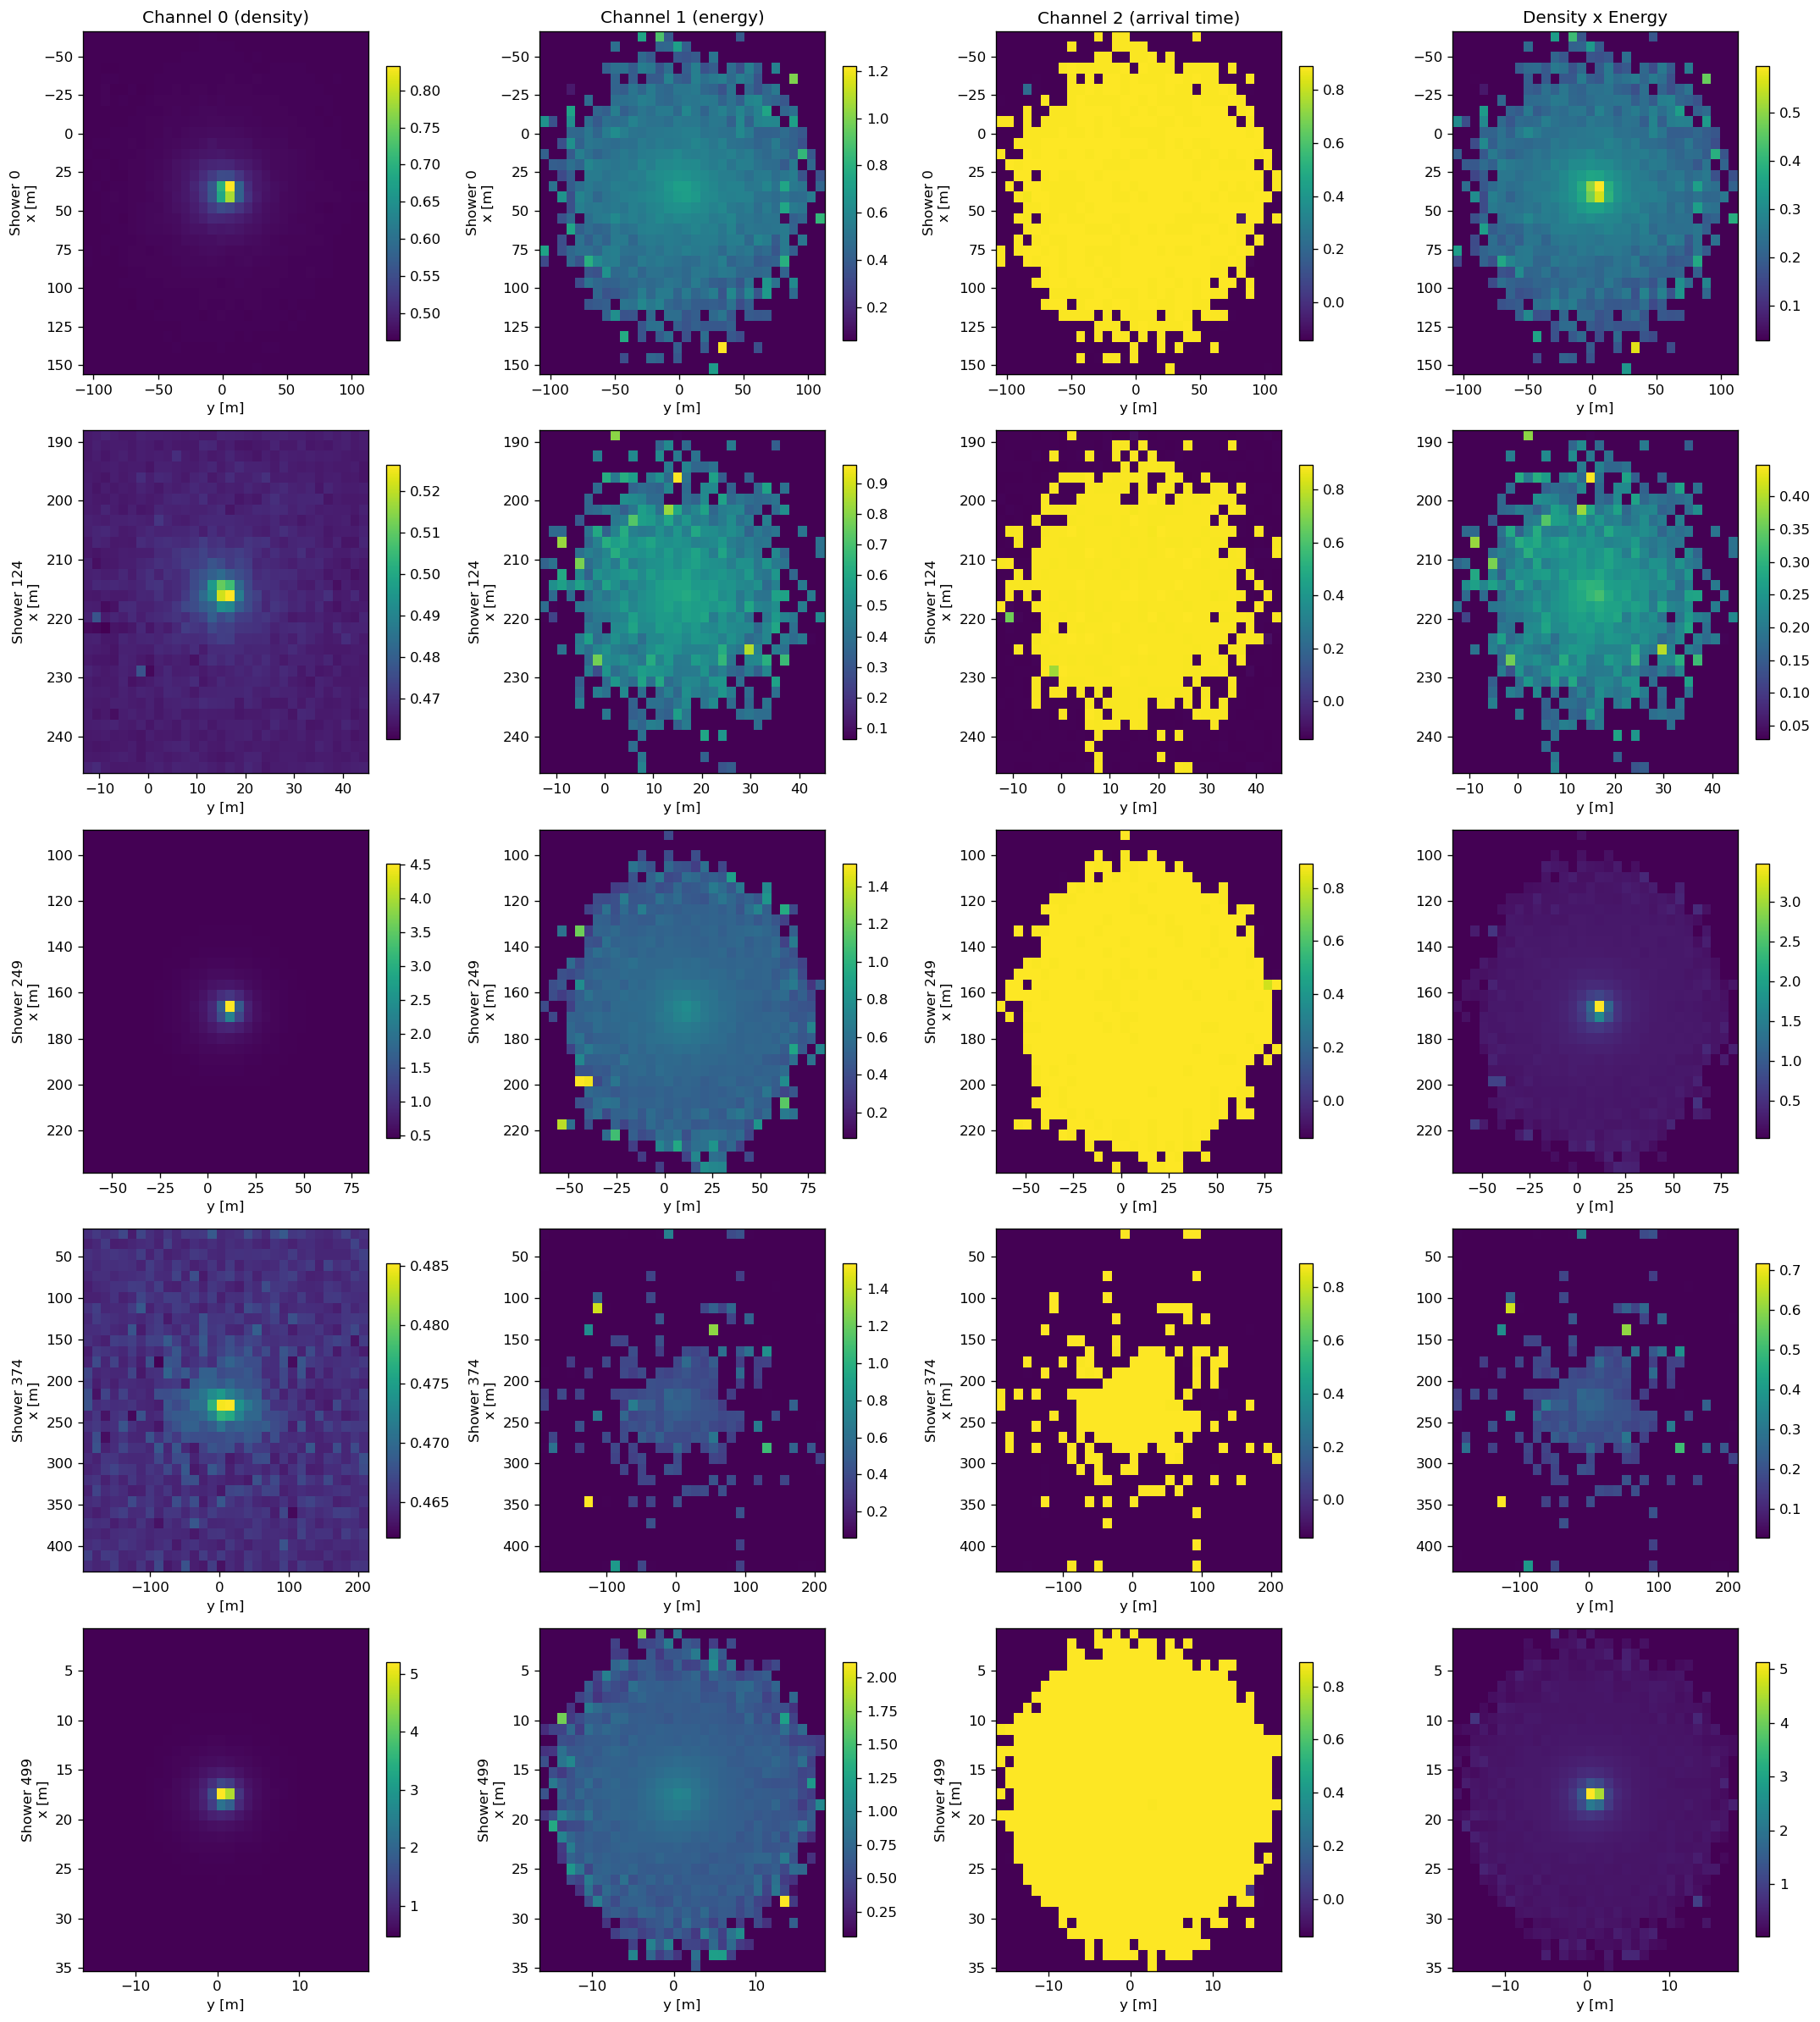

In [5]:
n_show = 5
indices = np.linspace(0, N - 1, n_show, dtype=int)
channel_names = ['Channel 0 (density)', 'Channel 1 (energy)', 'Channel 2 (arrival time)', 'Density x Energy']

fig, axes = plt.subplots(n_show, 4, figsize=(18, 4 * n_show))

for row, idx in enumerate(indices):
    bbox = bboxes[idx]
    extent = [bbox[2].item(), bbox[3].item(), bbox[1].item(), bbox[0].item()]  # [y_min, y_max, x_max, x_min]

    for ch in range(3):
        im = axes[row, ch].imshow(
            shower_rgb[idx, :, :, ch].numpy(), extent=extent, aspect='auto'
        )
        fig.colorbar(im, ax=axes[row, ch], shrink=0.8)
        if row == 0:
            axes[row, ch].set_title(channel_names[ch])
        axes[row, ch].set_ylabel(f'Shower {idx}\nx [m]')
        axes[row, ch].set_xlabel('y [m]')

    # Combined
    im = axes[row, 3].imshow(
        density_energy[idx].numpy(), extent=extent, aspect='auto'
    )
    fig.colorbar(im, ax=axes[row, 3], shrink=0.8)
    if row == 0:
        axes[row, 3].set_title(channel_names[3])
    axes[row, 3].set_xlabel('y [m]')

plt.tight_layout()
plt.show()

## 5. Resample onto Common Physical Grid & Compute Average Shower

Each shower lives in its own bounding box, so before computing mean/std we resample
every shower onto a **common physical coordinate grid** that spans the union of all
bounding boxes.  Pixels outside a shower's bbox contribute zero and are excluded
from the count, so the average is taken only over showers that actually cover each
physical location.

In [6]:
# ── Common physical grid spanning all bounding boxes ─────────────────
x_lo = bboxes[:, 0].min().item()
x_hi = bboxes[:, 1].max().item()
y_lo = bboxes[:, 2].min().item()
y_hi = bboxes[:, 3].max().item()

COMMON_RES = 64                                        # output grid resolution
x_phys = torch.linspace(x_lo, x_hi, COMMON_RES)       # rows  = x [m]
y_phys = torch.linspace(y_lo, y_hi, COMMON_RES)       # cols  = y [m]
x_grid, y_grid = torch.meshgrid(x_phys, y_phys, indexing='ij')  # (R, R)

print(f"Common grid: x in [{x_lo:.1f}, {x_hi:.1f}] m,  y in [{y_lo:.1f}, {y_hi:.1f}] m")
print(f"Resolution : {COMMON_RES} x {COMMON_RES}")


def resample_to_common_grid(shower_rgb_sub, density_energy_sub, bboxes_sub):
    """Resample a batch of showers onto the common physical grid.

    Returns
    -------
    running_sum   : (R, R, 4)  -- accumulated channel values (ch0-2 + density x energy)
    running_sq    : (R, R, 4)  -- accumulated squared values
    running_count : (R, R)     -- number of showers covering each grid cell
    """
    R = COMMON_RES
    r_sum   = torch.zeros(R, R, 4)
    r_sq    = torch.zeros(R, R, 4)
    r_count = torch.zeros(R, R)

    BATCH = 1000
    n = shower_rgb_sub.shape[0]
    for s in range(0, n, BATCH):
        e = min(s + BATCH, n)
        B = e - s

        # (B, 3, 32, 32) + (B, 1, 32, 32) -> (B, 4, 32, 32)
        inp = torch.cat([
            shower_rgb_sub[s:e].permute(0, 3, 1, 2),
            density_energy_sub[s:e].unsqueeze(1)
        ], dim=1)

        x_min_b = bboxes_sub[s:e, 0].view(-1, 1, 1)
        x_max_b = bboxes_sub[s:e, 1].view(-1, 1, 1)
        y_min_b = bboxes_sub[s:e, 2].view(-1, 1, 1)
        y_max_b = bboxes_sub[s:e, 3].view(-1, 1, 1)

        # Normalise common-grid coords into each shower's [-1, 1] pixel space
        x_norm = 2 * (x_grid.unsqueeze(0) - x_min_b) / (x_max_b - x_min_b) - 1
        y_norm = 2 * (y_grid.unsqueeze(0) - y_min_b) / (y_max_b - y_min_b) - 1

        # grid_sample convention: grid[...,0]=W(y), grid[...,1]=H(x)
        grid = torch.stack([y_norm, x_norm], dim=-1)  # (B, R, R, 2)

        resampled = F.grid_sample(
            inp, grid, mode='bilinear', padding_mode='zeros', align_corners=True
        ).permute(0, 2, 3, 1)  # (B, R, R, 4)

        valid = (x_norm >= -1) & (x_norm <= 1) & (y_norm >= -1) & (y_norm <= 1)

        r_sum   += (resampled * valid.unsqueeze(-1)).sum(dim=0)
        r_sq    += (resampled**2 * valid.unsqueeze(-1)).sum(dim=0)
        r_count += valid.float().sum(dim=0)

    return r_sum, r_sq, r_count


# ── Compute over ALL showers ─────────────────────────────────────────
r_sum, r_sq, r_count = resample_to_common_grid(shower_rgb, density_energy, bboxes)

mean_resampled = r_sum / (r_count.unsqueeze(-1) + 1e-8)
var_resampled  = r_sq / (r_count.unsqueeze(-1) + 1e-8) - mean_resampled**2
std_resampled  = torch.sqrt(var_resampled.clamp(min=0))

# Split into channels
mean_shower = mean_resampled[:, :, :3]   # (R, R, 3)
std_shower  = std_resampled[:, :, :3]
mean_de     = mean_resampled[:, :, 3]    # (R, R)
std_de      = std_resampled[:, :, 3]

print("\n=== Per-channel statistics (on common physical grid) ===")
for ch, name in enumerate(['Density (ch0)', 'Energy (ch1)', 'Arrival Time (ch2)']):
    m = mean_shower[:, :, ch]
    s = std_shower[:, :, ch]
    print(f"  {name}: mean={m.mean():.4f}, std={s.mean():.4f}, "
          f"min={m.min():.4f}, max={m.max():.4f}")
print(f"  Density x Energy: mean={mean_de.mean():.4f}, std={std_de.mean():.4f}, "
      f"min={mean_de.min():.4f}, max={mean_de.max():.4f}")
print(f"  Max coverage count: {r_count.max():.0f} / {N}")

Common grid: x in [-190.6, 784.1] m,  y in [-200.2, 274.4] m
Resolution : 64 x 64

=== Per-channel statistics (on common physical grid) ===
  Density (ch0): mean=0.4335, std=0.0263, min=0.0000, max=0.8894
  Energy (ch1): mean=0.1750, std=0.1901, min=0.0000, max=0.9472
  Arrival Time (ch2): mean=0.0955, std=0.2481, min=-0.1414, max=0.8487
  Density x Energy: mean=0.0867, std=0.1264, min=0.0000, max=1.0628
  Max coverage count: 190 / 500


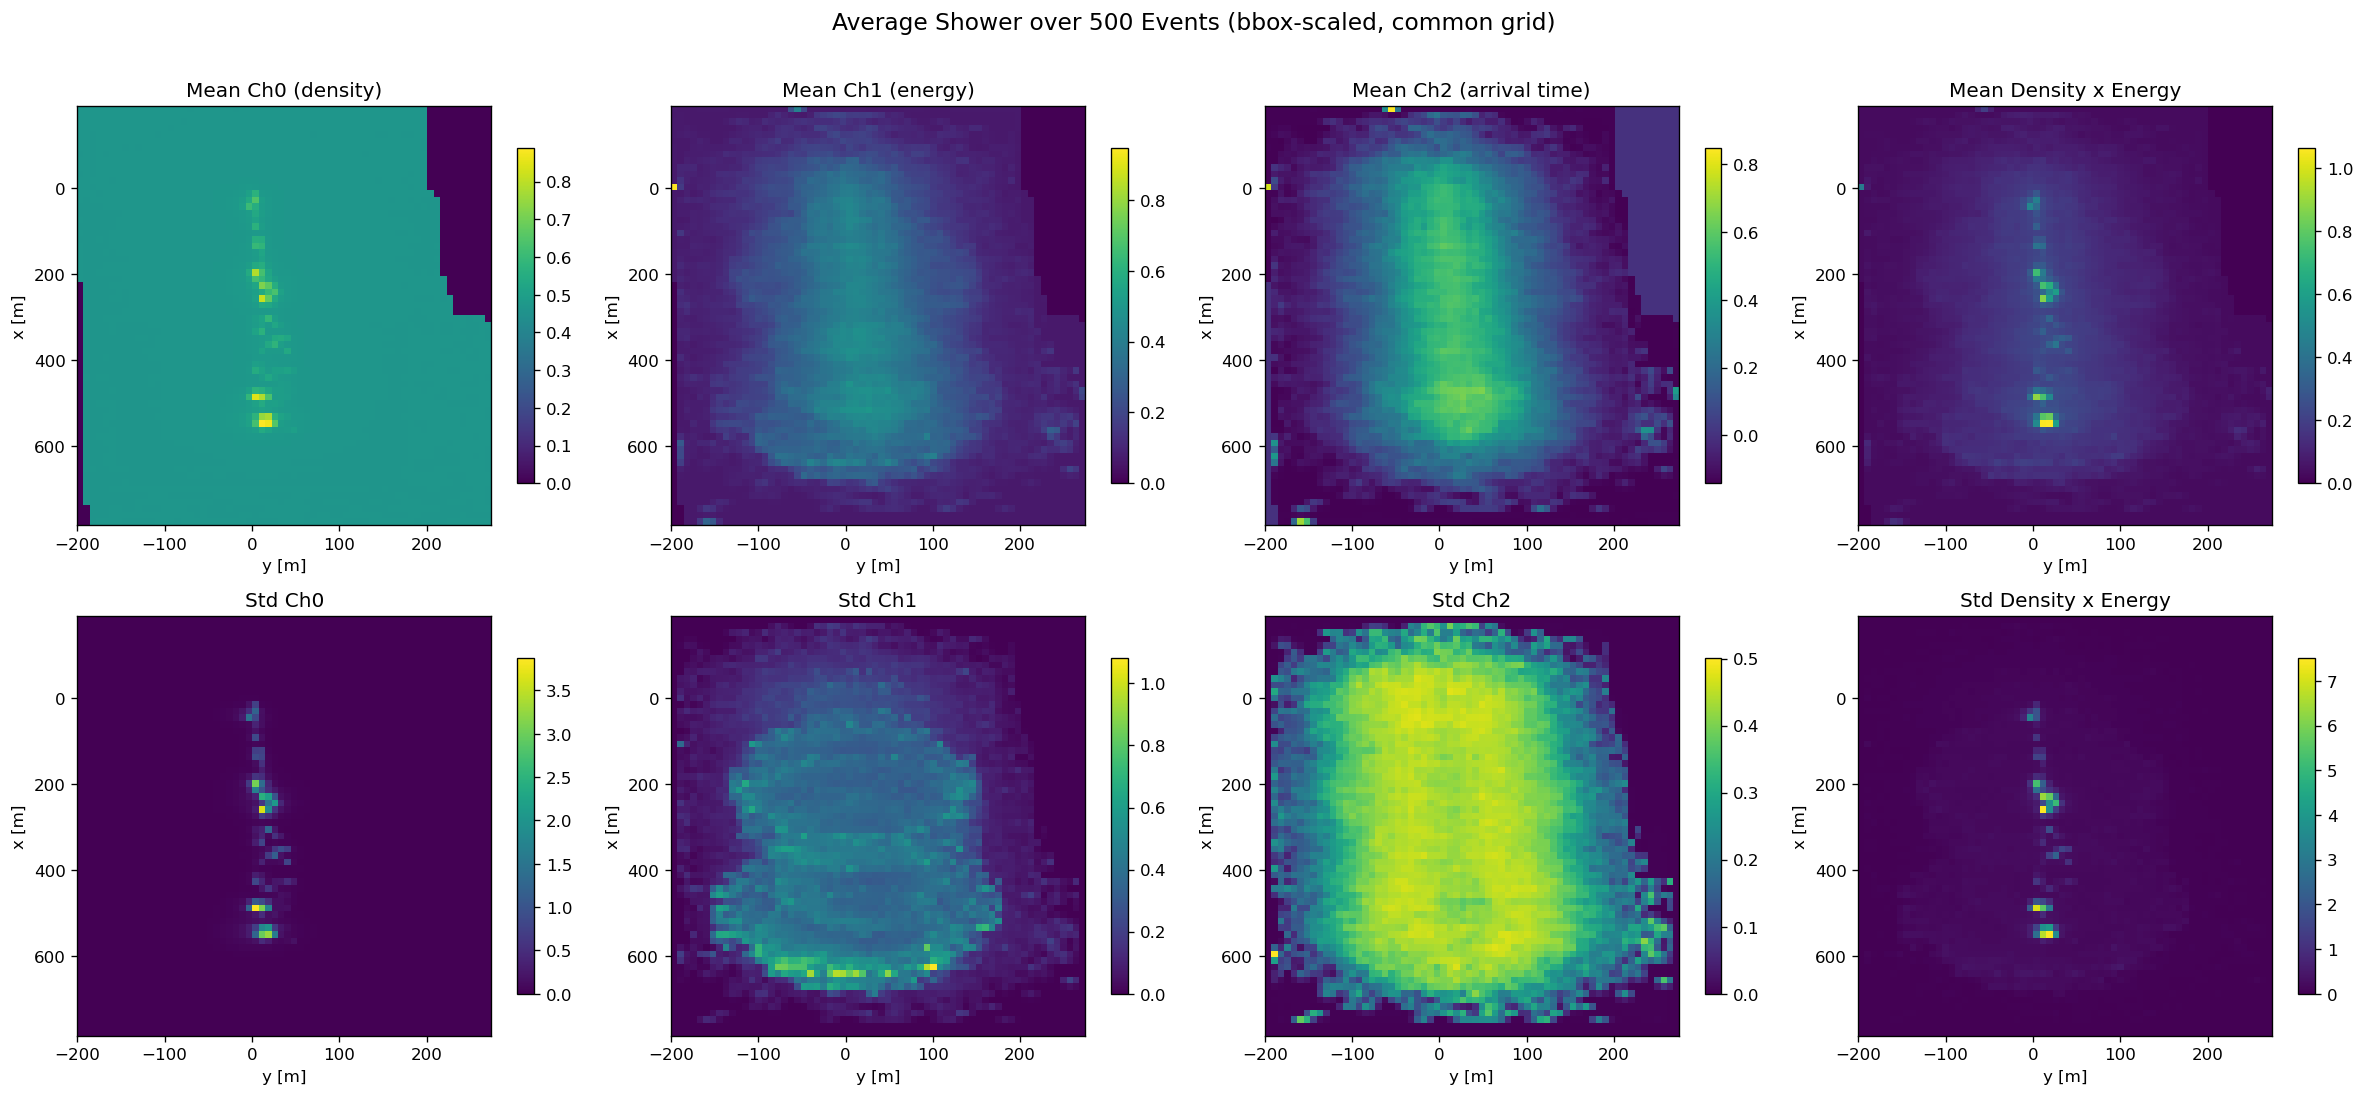

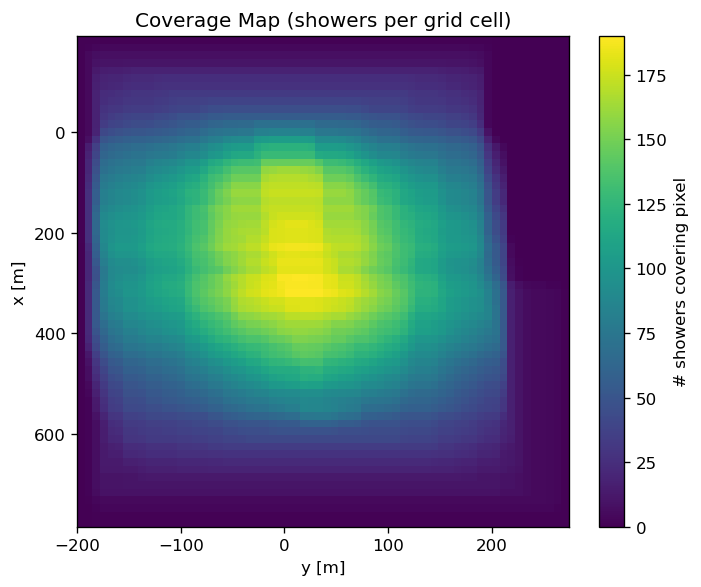

In [7]:
extent_common = [y_lo, y_hi, x_hi, x_lo]   # imshow extent: [left, right, bottom, top]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

titles_top = ['Mean Ch0 (density)', 'Mean Ch1 (energy)', 'Mean Ch2 (arrival time)', 'Mean Density x Energy']
titles_bot = ['Std Ch0', 'Std Ch1', 'Std Ch2', 'Std Density x Energy']

# Mean row
for ch in range(3):
    im = axes[0, ch].imshow(mean_shower[:, :, ch].numpy(), extent=extent_common, aspect='auto')
    fig.colorbar(im, ax=axes[0, ch], shrink=0.8)
    axes[0, ch].set_title(titles_top[ch])

im = axes[0, 3].imshow(mean_de.numpy(), extent=extent_common, aspect='auto')
fig.colorbar(im, ax=axes[0, 3], shrink=0.8)
axes[0, 3].set_title(titles_top[3])

# Std row
for ch in range(3):
    im = axes[1, ch].imshow(std_shower[:, :, ch].numpy(), extent=extent_common, aspect='auto')
    fig.colorbar(im, ax=axes[1, ch], shrink=0.8)
    axes[1, ch].set_title(titles_bot[ch])

im = axes[1, 3].imshow(std_de.numpy(), extent=extent_common, aspect='auto')
fig.colorbar(im, ax=axes[1, 3], shrink=0.8)
axes[1, 3].set_title(titles_bot[3])

for ax in axes.flat:
    ax.set_xlabel('y [m]')
    ax.set_ylabel('x [m]')

plt.suptitle(f'Average Shower over {N} Events (bbox-scaled, common grid)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Coverage map
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r_count.numpy(), extent=extent_common, aspect='auto', cmap='viridis')
fig.colorbar(im, ax=ax, label='# showers covering pixel')
ax.set_xlabel('y [m]')
ax.set_ylabel('x [m]')
ax.set_title('Coverage Map (showers per grid cell)')
plt.tight_layout()
plt.show()

## 6. Average Shower by Energy Bins (bbox-scaled)

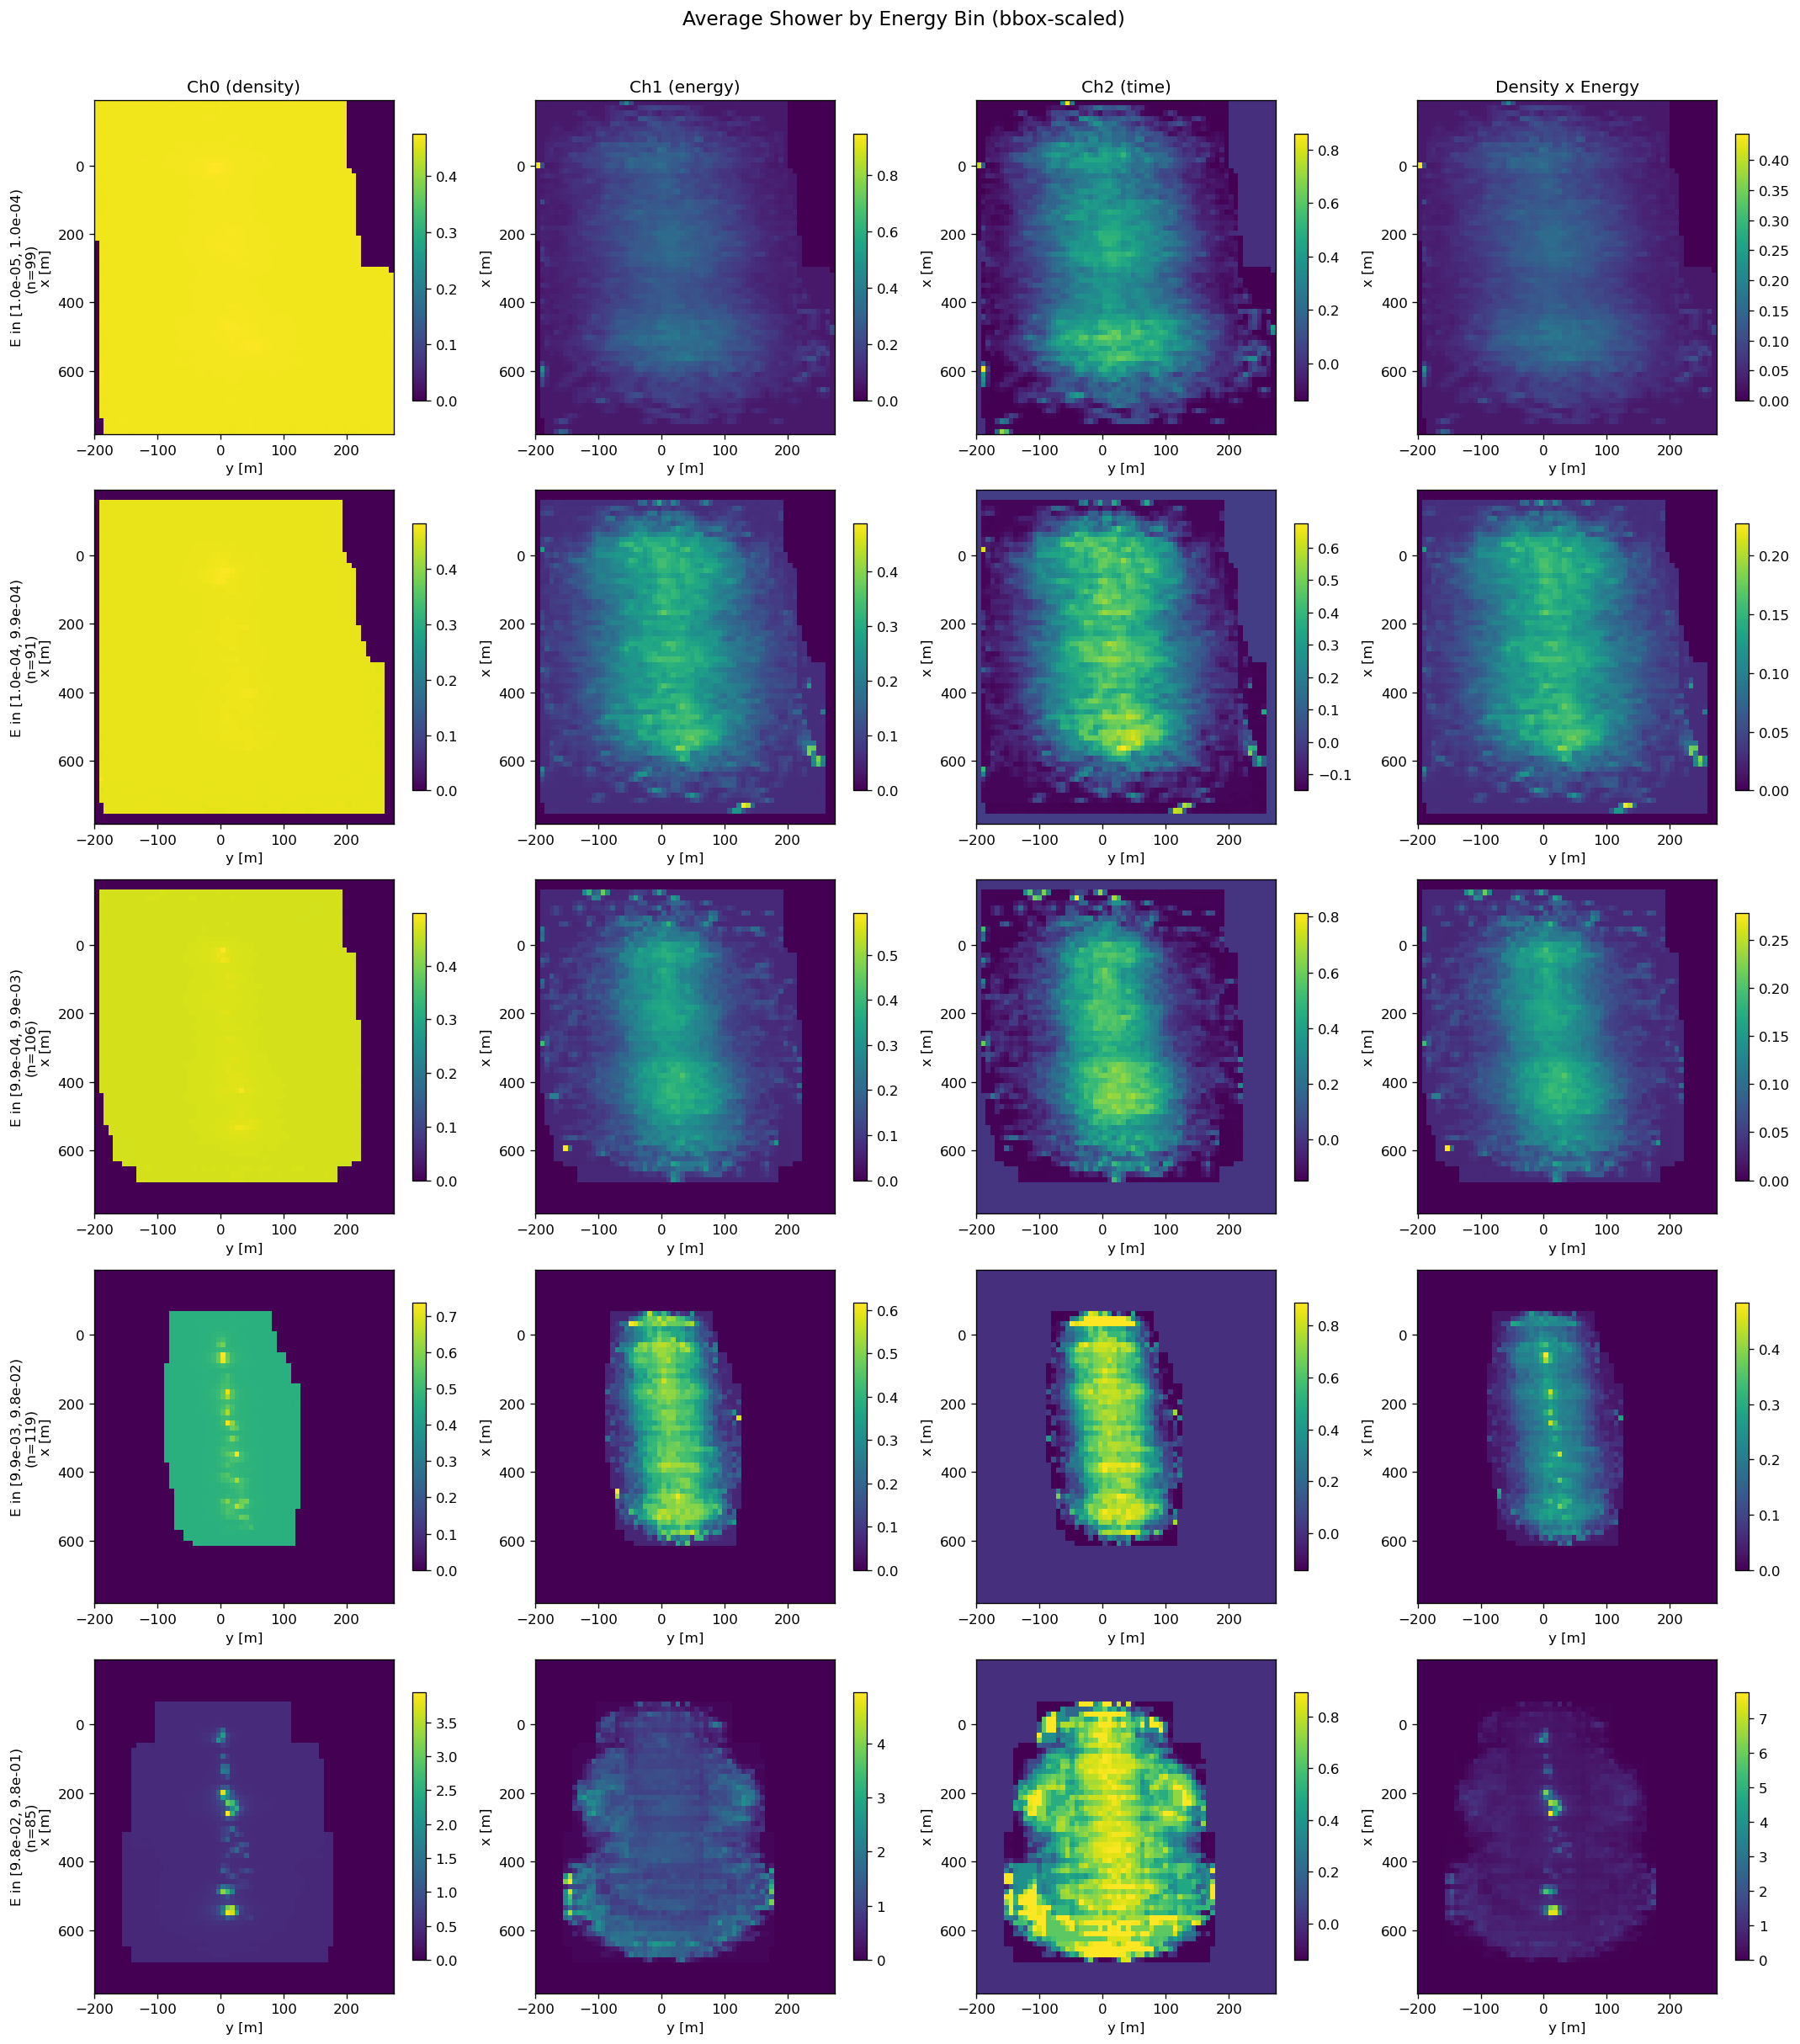

In [8]:
# Log-spaced energy bins
log_e = torch.log10(p_energy)
n_bins = 5
bin_edges = torch.linspace(log_e.min(), log_e.max(), n_bins + 1)

fig, axes = plt.subplots(n_bins, 4, figsize=(18, 4 * n_bins))

for b in range(n_bins):
    mask = (log_e >= bin_edges[b]) & (log_e < bin_edges[b + 1])
    if b == n_bins - 1:  # include right edge in last bin
        mask = mask | (log_e == bin_edges[b + 1])
    count = mask.sum().item()

    if count == 0:
        for col in range(4):
            axes[b, col].text(0.5, 0.5, 'No events', ha='center', va='center',
                              transform=axes[b, col].transAxes)
        continue

    rs, _, rc = resample_to_common_grid(shower_rgb[mask], density_energy[mask], bboxes[mask])
    avg = rs / (rc.unsqueeze(-1) + 1e-8)
    avg_rgb = avg[:, :, :3]
    avg_de  = avg[:, :, 3]

    e_lo = 10 ** bin_edges[b].item()
    e_hi = 10 ** bin_edges[b + 1].item()

    for ch in range(3):
        im = axes[b, ch].imshow(avg_rgb[:, :, ch].numpy(), extent=extent_common, aspect='auto')
        fig.colorbar(im, ax=axes[b, ch], shrink=0.8)
        if b == 0:
            axes[b, ch].set_title(['Ch0 (density)', 'Ch1 (energy)', 'Ch2 (time)'][ch])
        axes[b, ch].set_xlabel('y [m]')
        axes[b, ch].set_ylabel('x [m]')

    im = axes[b, 3].imshow(avg_de.numpy(), extent=extent_common, aspect='auto')
    fig.colorbar(im, ax=axes[b, 3], shrink=0.8)
    if b == 0:
        axes[b, 3].set_title('Density x Energy')
    axes[b, 3].set_xlabel('y [m]')
    axes[b, 3].set_ylabel('x [m]')

    axes[b, 0].set_ylabel(f'E in [{e_lo:.1e}, {e_hi:.1e})\n(n={count})\nx [m]')

plt.suptitle('Average Shower by Energy Bin (bbox-scaled)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Average Shower by Zenith Angle Bins (bbox-scaled)

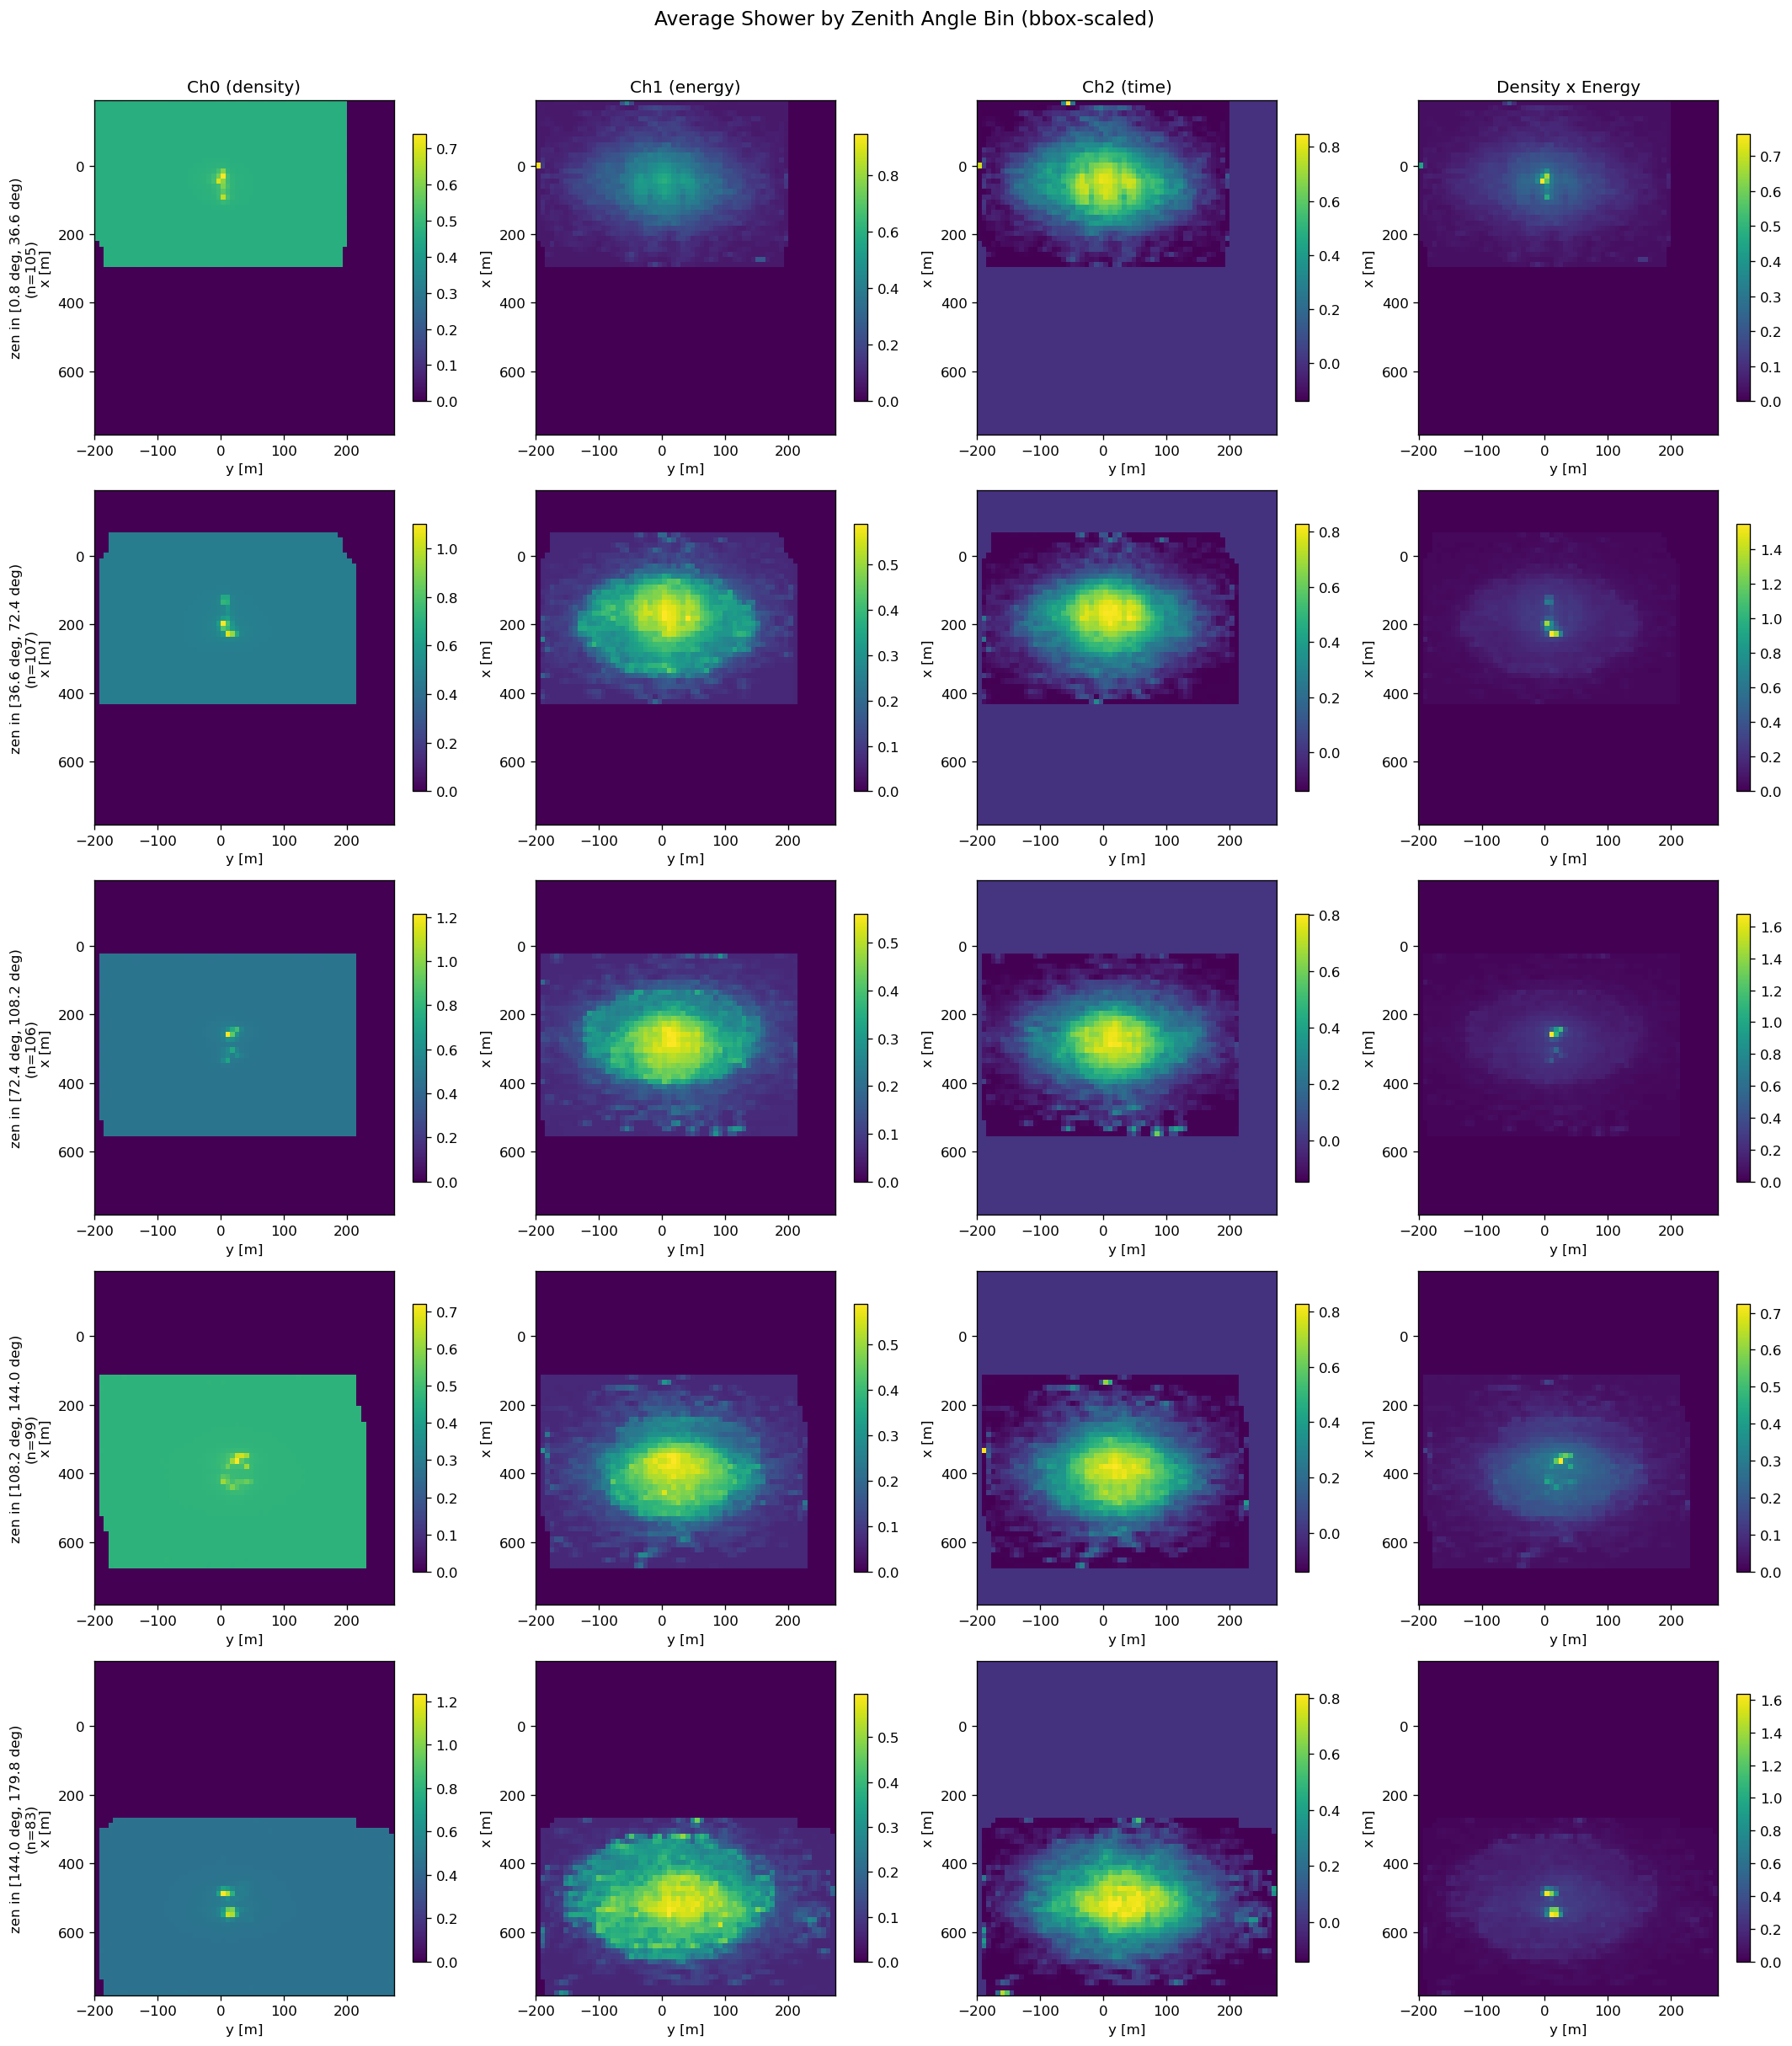

In [9]:
zenith_deg = np.degrees(zenith.numpy())
n_zbins = 5
zbin_edges = np.linspace(zenith_deg.min(), zenith_deg.max(), n_zbins + 1)

fig, axes = plt.subplots(n_zbins, 4, figsize=(18, 4 * n_zbins))

for b in range(n_zbins):
    mask_np = (zenith_deg >= zbin_edges[b]) & (zenith_deg < zbin_edges[b + 1])
    if b == n_zbins - 1:
        mask_np = mask_np | (zenith_deg == zbin_edges[b + 1])
    mask_t = torch.from_numpy(mask_np)
    count = mask_t.sum().item()

    if count == 0:
        for col in range(4):
            axes[b, col].text(0.5, 0.5, 'No events', ha='center', va='center',
                              transform=axes[b, col].transAxes)
        continue

    rs, _, rc = resample_to_common_grid(shower_rgb[mask_t], density_energy[mask_t], bboxes[mask_t])
    avg = rs / (rc.unsqueeze(-1) + 1e-8)
    avg_rgb = avg[:, :, :3]
    avg_de  = avg[:, :, 3]

    for ch in range(3):
        im = axes[b, ch].imshow(avg_rgb[:, :, ch].numpy(), extent=extent_common, aspect='auto')
        fig.colorbar(im, ax=axes[b, ch], shrink=0.8)
        if b == 0:
            axes[b, ch].set_title(['Ch0 (density)', 'Ch1 (energy)', 'Ch2 (time)'][ch])
        axes[b, ch].set_xlabel('y [m]')
        axes[b, ch].set_ylabel('x [m]')

    im = axes[b, 3].imshow(avg_de.numpy(), extent=extent_common, aspect='auto')
    fig.colorbar(im, ax=axes[b, 3], shrink=0.8)
    if b == 0:
        axes[b, 3].set_title('Density x Energy')
    axes[b, 3].set_xlabel('y [m]')
    axes[b, 3].set_ylabel('x [m]')

    axes[b, 0].set_ylabel(f'zen in [{zbin_edges[b]:.1f} deg, {zbin_edges[b+1]:.1f} deg)\n(n={count})\nx [m]')

plt.suptitle('Average Shower by Zenith Angle Bin (bbox-scaled)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Average Shower by Azimuth Angle Bins (bbox-scaled)

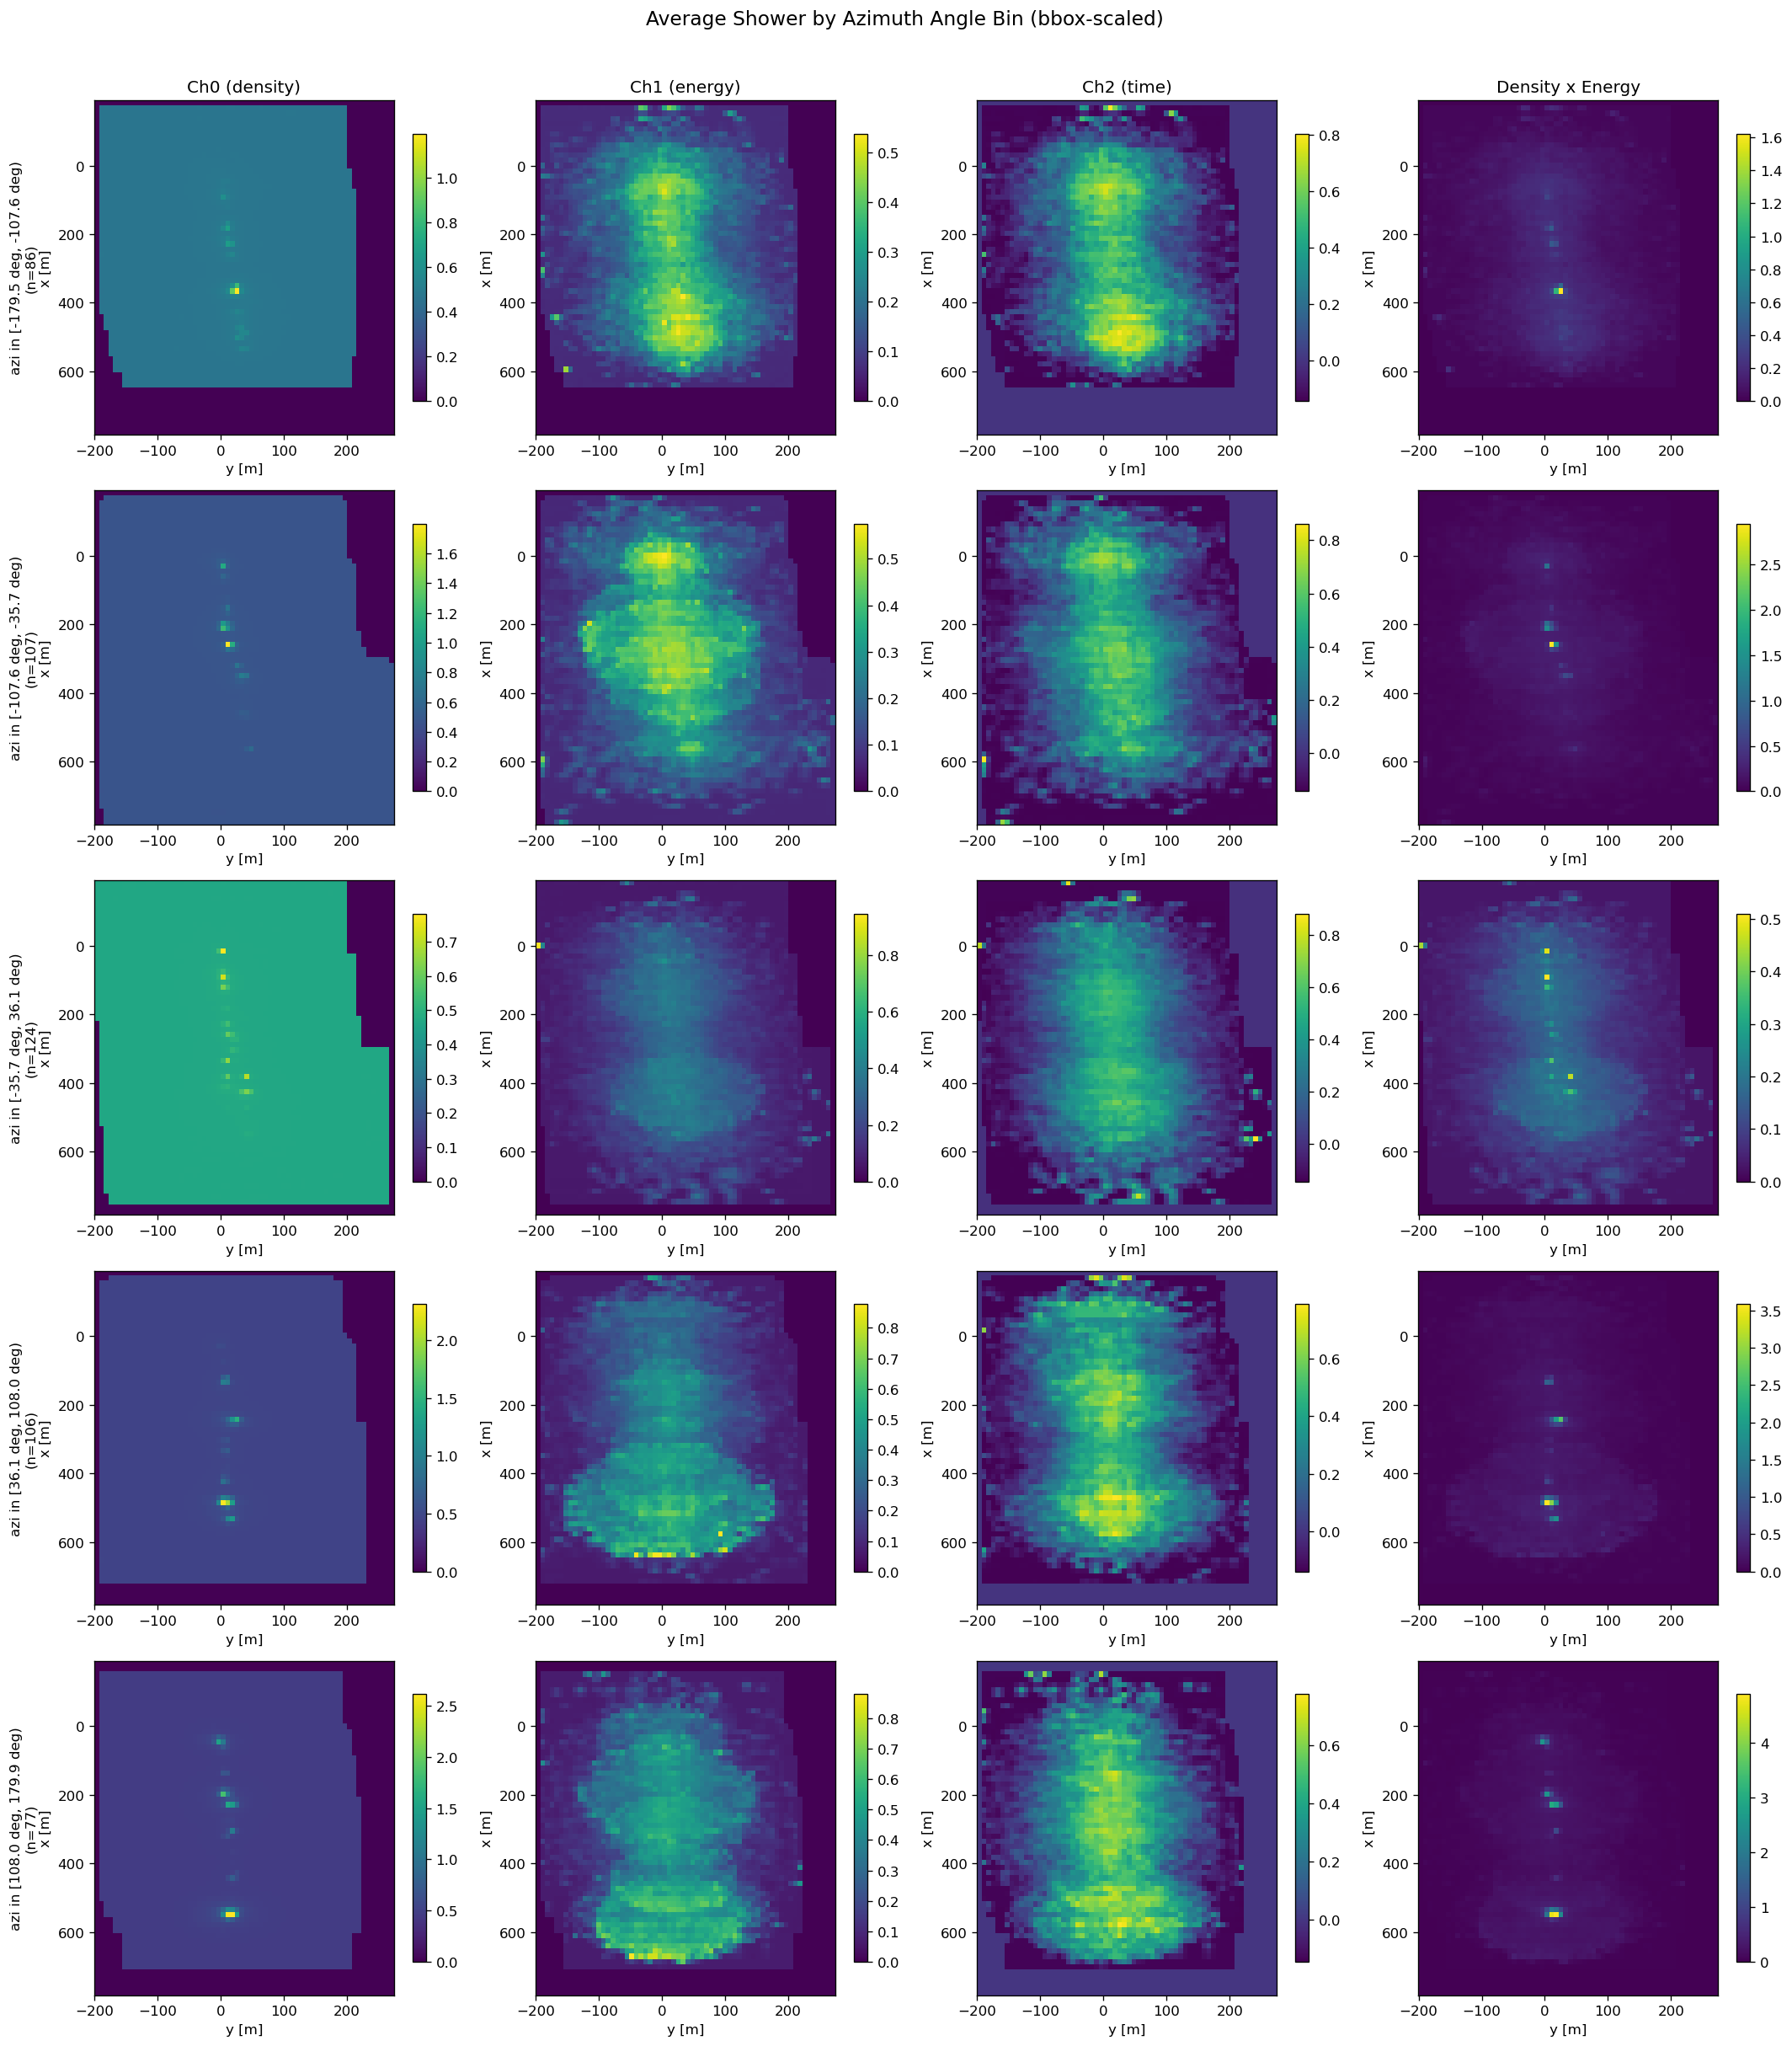

In [18]:
azimuth_deg = np.degrees(azimuth.numpy())
n_zbins = 5
zbin_edges = np.linspace(azimuth_deg.min(), azimuth_deg.max(), n_zbins + 1)

fig, axes = plt.subplots(n_zbins, 4, figsize=(18, 4 * n_zbins))

for b in range(n_zbins):
    mask_np = (azimuth_deg >= zbin_edges[b]) & (azimuth_deg < zbin_edges[b + 1])
    if b == n_zbins - 1:
        mask_np = mask_np | (azimuth_deg == zbin_edges[b + 1])
    mask_t = torch.from_numpy(mask_np)
    count = mask_t.sum().item()

    if count == 0:
        for col in range(4):
            axes[b, col].text(0.5, 0.5, 'No events', ha='center', va='center',
                              transform=axes[b, col].transAxes)
        continue

    rs, _, rc = resample_to_common_grid(shower_rgb[mask_t], density_energy[mask_t], bboxes[mask_t])
    avg = rs / (rc.unsqueeze(-1) + 1e-8)
    avg_rgb = avg[:, :, :3]
    avg_de  = avg[:, :, 3]

    for ch in range(3):
        im = axes[b, ch].imshow(avg_rgb[:, :, ch].numpy(), extent=extent_common, aspect='auto')
        fig.colorbar(im, ax=axes[b, ch], shrink=0.8)
        if b == 0:
            axes[b, ch].set_title(['Ch0 (density)', 'Ch1 (energy)', 'Ch2 (time)'][ch])
        axes[b, ch].set_xlabel('y [m]')
        axes[b, ch].set_ylabel('x [m]')

    im = axes[b, 3].imshow(avg_de.numpy(), extent=extent_common, aspect='auto')
    fig.colorbar(im, ax=axes[b, 3], shrink=0.8)
    if b == 0:
        axes[b, 3].set_title('Density x Energy')
    axes[b, 3].set_xlabel('y [m]')
    axes[b, 3].set_ylabel('x [m]')

    axes[b, 0].set_ylabel(f'azi in [{zbin_edges[b]:.1f} deg, {zbin_edges[b+1]:.1f} deg)\n(n={count})\nx [m]')

plt.suptitle('Average Shower by Azimuth Angle Bin (bbox-scaled)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Comparing Mean Showers Across Narrow Angle Ranges

To isolate the influence of **zenith** (elevation) and **azimuth** on the shower
morphology, we select a few narrow angular slices (each ~15-20 deg wide) and
plot the bbox-scaled mean Density x Energy map for each slice side-by-side.

- **Top block:** fixed azimuth range, varying zenith
- **Bottom block:** fixed zenith range, varying azimuth

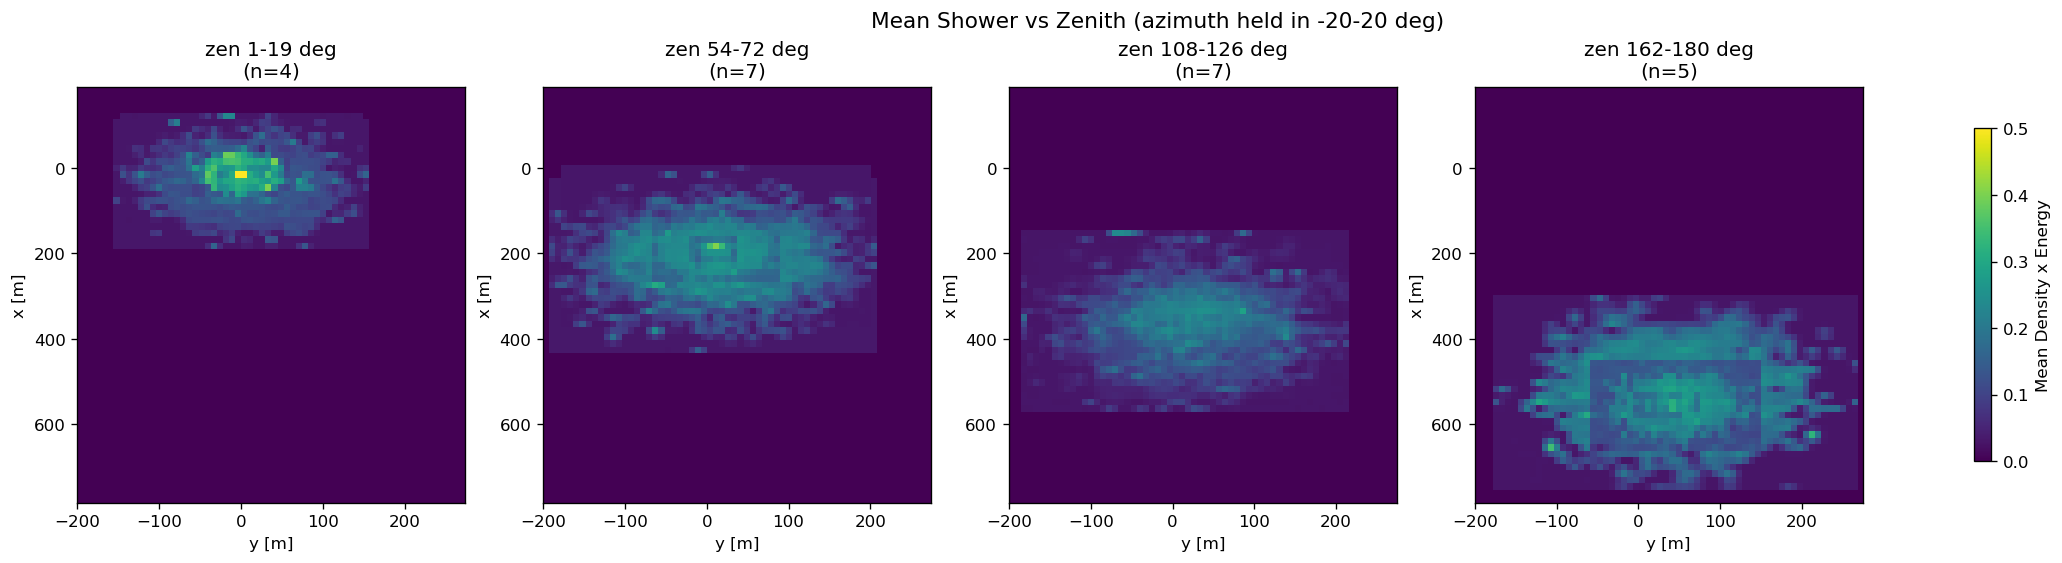

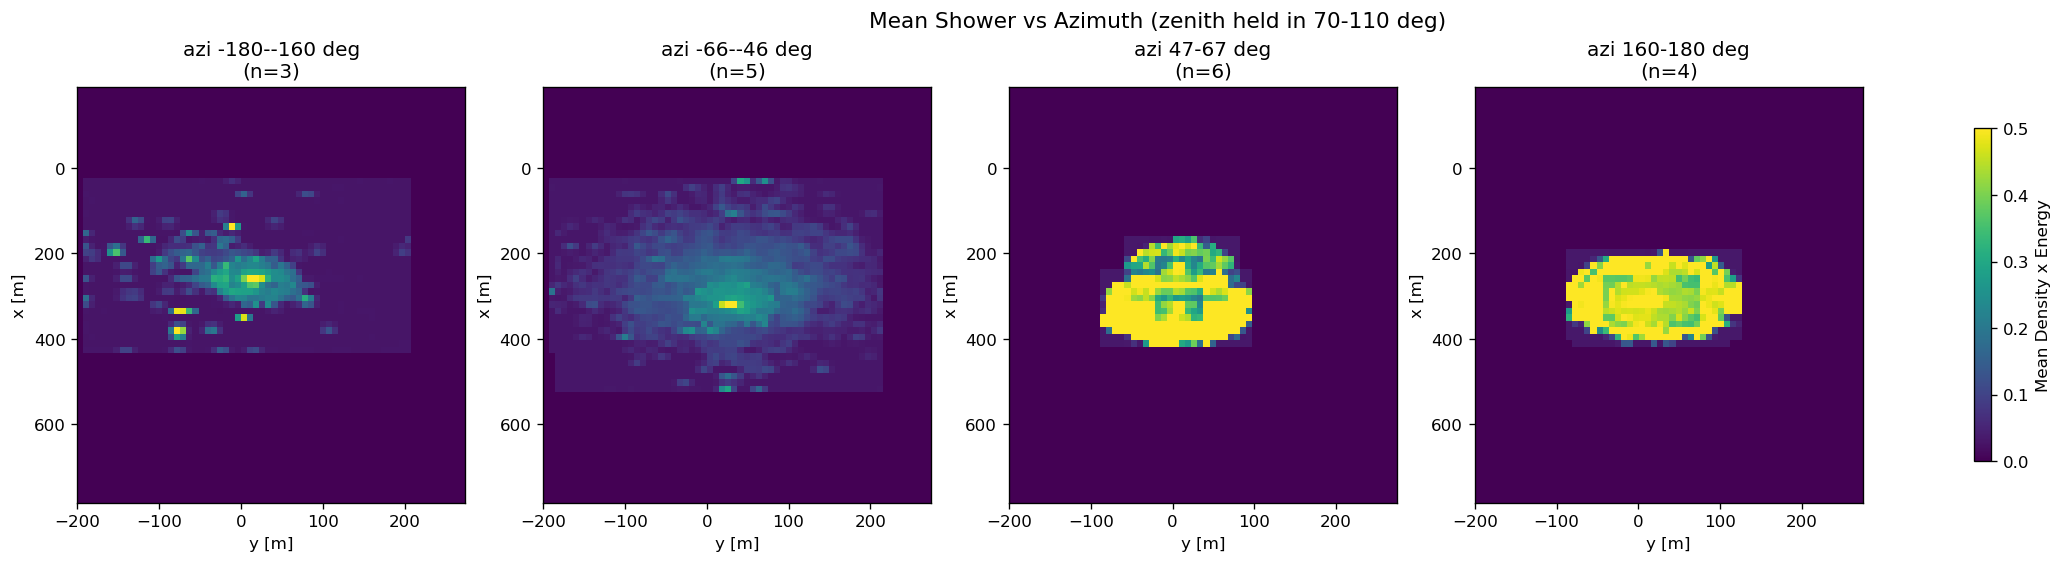

In [17]:
# ── Helper: compute mean on common grid for a boolean mask ───────────
def mean_on_grid(mask_t):
    """Return (mean_de, count) for showers selected by mask_t."""
    rs, _, rc = resample_to_common_grid(
        shower_rgb[mask_t], density_energy[mask_t], bboxes[mask_t]
    )
    avg = rs / (rc.unsqueeze(-1) + 1e-8)
    return avg[:, :, 3], rc   # mean density x energy, coverage

zenith_deg  = np.degrees(zenith.numpy())
azimuth_deg = np.degrees(azimuth.numpy())

# ── Define narrow slices ─────────────────────────────────────────────
# Zenith slices (narrow bands)
zen_width = 18.0  # degrees per slice
zen_centers = np.linspace(
    zenith_deg.min() + zen_width / 2,
    zenith_deg.max() - zen_width / 2,
    4
)
zen_slices = [(c - zen_width / 2, c + zen_width / 2) for c in zen_centers]

# Azimuth slices (narrow bands)
azi_width = 20.0
azi_centers = np.linspace(
    azimuth_deg.min() + azi_width / 2,
    azimuth_deg.max() - azi_width / 2,
    4
)
azi_slices = [(c - azi_width / 2, c + azi_width / 2) for c in azi_centers]

# ── Pick a broad azimuth band for the zenith comparison ──────────────
azi_mid = (azimuth_deg.min() + azimuth_deg.max()) / 2
azi_band = 40.0  # keep this wide enough to have statistics
azi_mask = (azimuth_deg >= azi_mid - azi_band / 2) & (azimuth_deg <= azi_mid + azi_band / 2)

# ── Pick a broad zenith band for the azimuth comparison ──────────────
zen_mid = (zenith_deg.min() + zenith_deg.max()) / 2
zen_band = 40.0
zen_mask = (zenith_deg >= zen_mid - zen_band / 2) & (zenith_deg <= zen_mid + zen_band / 2)

# ══════════════════════════════════════════════════════════════════════
# PLOT 1 : varying ZENITH, fixed broad azimuth band
# ══════════════════════════════════════════════════════════════════════
n_slices = len(zen_slices)
fig, axes = plt.subplots(1, n_slices, figsize=(6 * n_slices, 4.5))

vmin_list, vmax_list, imgs = [], [], []
for i, (zlo, zhi) in enumerate(zen_slices):
    mask_np = azi_mask & (zenith_deg >= zlo) & (zenith_deg <= zhi)
    mask_t = torch.from_numpy(mask_np)
    cnt = mask_t.sum().item()
    if cnt < 2:
        axes[i].text(0.5, 0.5, f'n={cnt}', ha='center', va='center',
                     transform=axes[i].transAxes)
        imgs.append(None)
        continue
    avg_de, _ = mean_on_grid(mask_t)
    arr = avg_de.numpy()
    imgs.append(arr)
    vmin_list.append(arr.min())
    vmax_list.append(arr.max())

# Use a shared colour scale
# if vmin_list:
#     vmin, vmax = np.mean(vmin_list) - 2 * np.std(vmin_list), np.mean(vmin_list) + 2 * np.std(vmin_list)
# else:
vmin, vmax = 0, 0.5

for i, (zlo, zhi) in enumerate(zen_slices):
    if imgs[i] is None:
        continue
    mask_np = azi_mask & (zenith_deg >= zlo) & (zenith_deg <= zhi)
    cnt = mask_np.sum()
    im = axes[i].imshow(imgs[i], extent=extent_common, aspect='auto',
                        vmin=vmin, vmax=vmax)
    axes[i].set_title(f'zen {zlo:.0f}-{zhi:.0f} deg\n(n={cnt})')
    axes[i].set_xlabel('y [m]')
    axes[i].set_ylabel('x [m]')

fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label='Mean Density x Energy')
fig.suptitle(
    f'Mean Shower vs Zenith (azimuth held in {azi_mid - azi_band/2:.0f}-{azi_mid + azi_band/2:.0f} deg)',
    fontsize=13, y=1.02
)
# plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 2 : varying AZIMUTH, fixed broad zenith band
# ══════════════════════════════════════════════════════════════════════
n_slices = len(azi_slices)
fig, axes = plt.subplots(1, n_slices, figsize=(6 * n_slices, 4.5))

vmin_list, vmax_list, imgs = [], [], []
for i, (alo, ahi) in enumerate(azi_slices):
    mask_np = zen_mask & (azimuth_deg >= alo) & (azimuth_deg <= ahi)
    mask_t = torch.from_numpy(mask_np)
    cnt = mask_t.sum().item()
    if cnt < 2:
        axes[i].text(0.5, 0.5, f'n={cnt}', ha='center', va='center',
                     transform=axes[i].transAxes)
        imgs.append(None)
        continue
    avg_de, _ = mean_on_grid(mask_t)
    arr = avg_de.numpy()
    imgs.append(arr)
    vmin_list.append(arr.min())
    vmax_list.append(arr.max())

# if vmin_list:
#     vmin, vmax = np.mean(vmin_list) - 2 * np.std(vmin_list), np.mean(vmin_list) + 2 * np.std(vmin_list)
# else:
vmin, vmax = 0, 0.5

for i, (alo, ahi) in enumerate(azi_slices):
    if imgs[i] is None:
        continue
    mask_np = zen_mask & (azimuth_deg >= alo) & (azimuth_deg <= ahi)
    cnt = mask_np.sum()
    im = axes[i].imshow(imgs[i], extent=extent_common, aspect='auto',
                        vmin=vmin, vmax=vmax)
    axes[i].set_title(f'azi {alo:.0f}-{ahi:.0f} deg\n(n={cnt})')
    axes[i].set_xlabel('y [m]')
    axes[i].set_ylabel('x [m]')

fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label='Mean Density x Energy')
fig.suptitle(
    f'Mean Shower vs Azimuth (zenith held in {zen_mid - zen_band/2:.0f}-{zen_mid + zen_band/2:.0f} deg)',
    fontsize=13, y=1.02
)
# plt.tight_layout()
plt.show()

## 9. Pixel-wise Statistics & Channel Correlations (bbox-scaled)

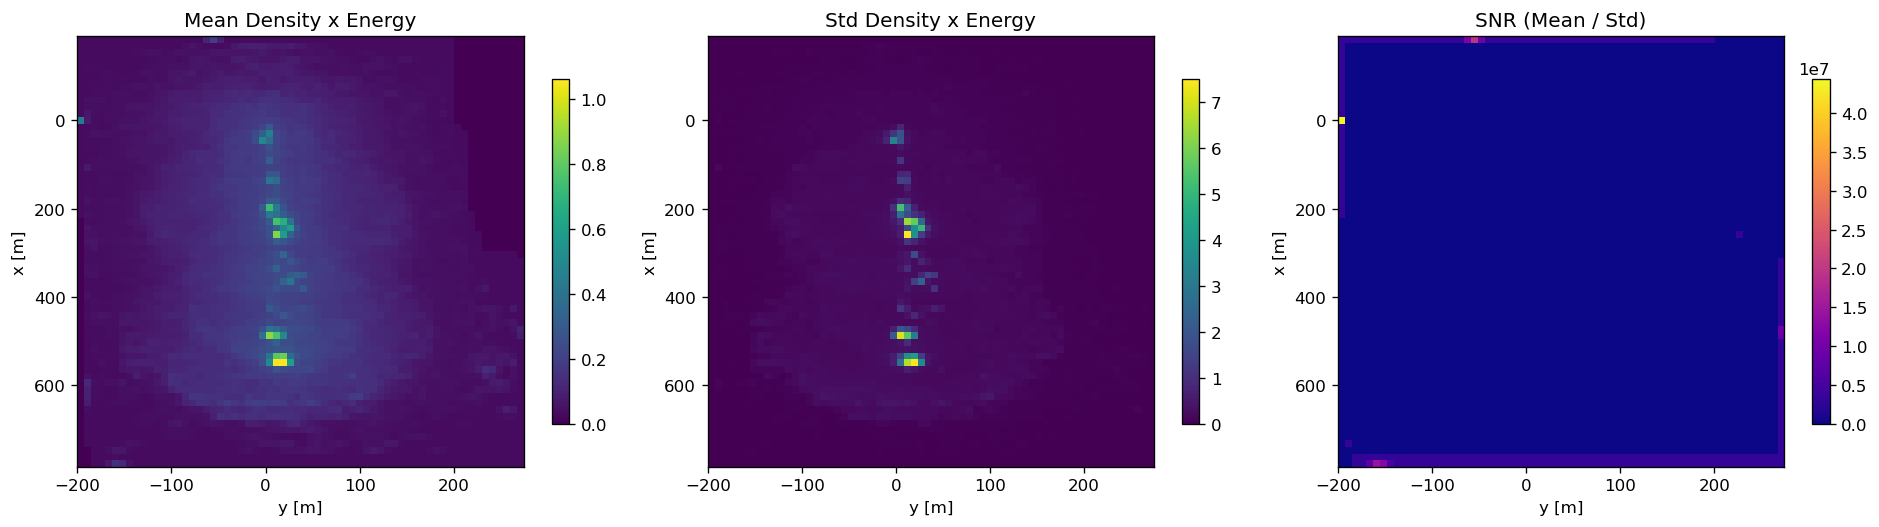

In [10]:
# Signal-to-noise ratio map (mean / std) on the common physical grid
snr_de = mean_de / (std_de + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im0 = axes[0].imshow(mean_de.numpy(), extent=extent_common, aspect='auto')
fig.colorbar(im0, ax=axes[0], shrink=0.8)
axes[0].set_title('Mean Density x Energy')

im1 = axes[1].imshow(std_de.numpy(), extent=extent_common, aspect='auto')
fig.colorbar(im1, ax=axes[1], shrink=0.8)
axes[1].set_title('Std Density x Energy')

im2 = axes[2].imshow(snr_de.numpy(), extent=extent_common, aspect='auto', cmap='plasma')
fig.colorbar(im2, ax=axes[2], shrink=0.8)
axes[2].set_title('SNR (Mean / Std)')

for ax in axes:
    ax.set_xlabel('y [m]')
    ax.set_ylabel('x [m]')

plt.tight_layout()
plt.show()

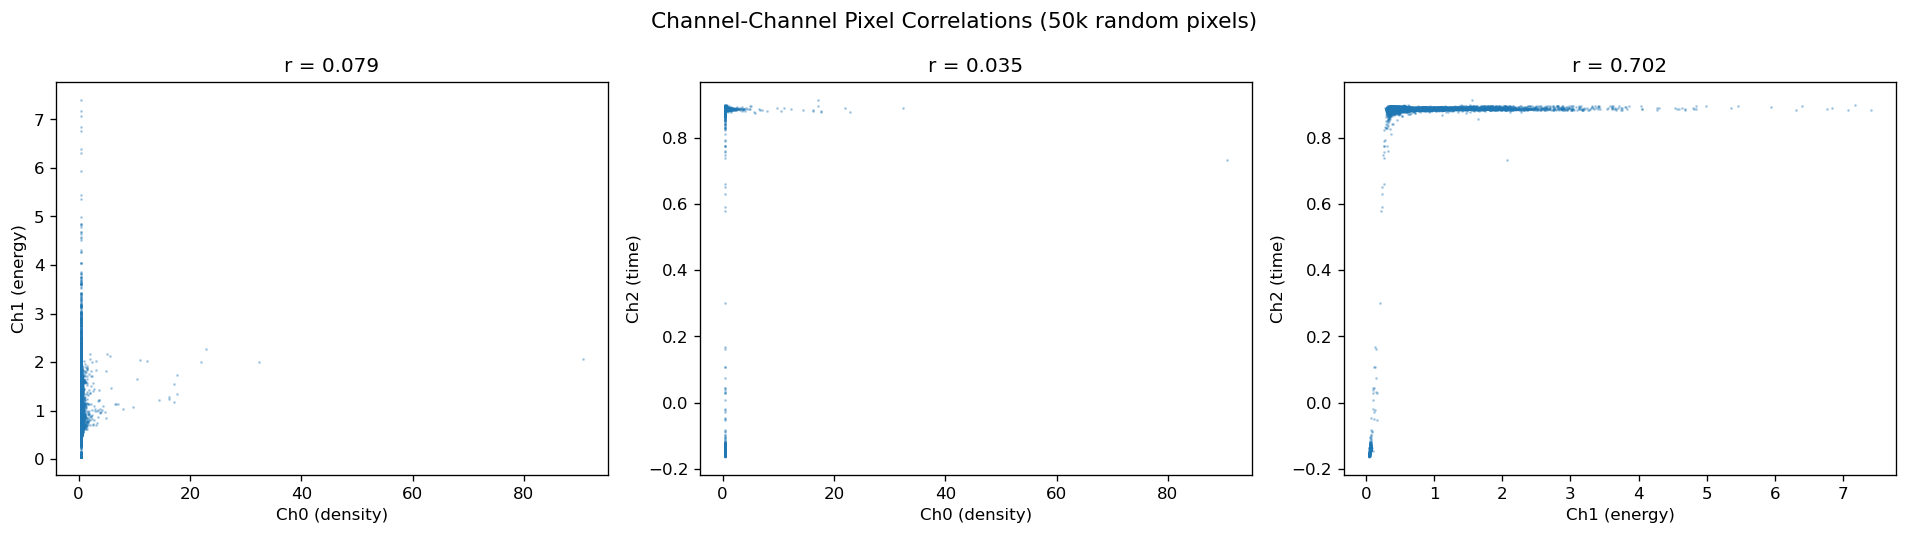

In [11]:
# Flatten all pixels across all showers for channel-channel scatter
flat = shower_rgb.reshape(-1, 3).numpy()

# Sub-sample for plotting speed
rng = np.random.default_rng(42)
idx_sub = rng.choice(len(flat), size=min(50_000, len(flat)), replace=False)
flat_sub = flat[idx_sub]

ch_labels = ['Ch0 (density)', 'Ch1 (energy)', 'Ch2 (time)']
pairs = [(0, 1), (0, 2), (1, 2)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (ci, cj) in zip(axes, pairs):
    ax.scatter(flat_sub[:, ci], flat_sub[:, cj], s=0.5, alpha=0.3)
    ax.set_xlabel(ch_labels[ci])
    ax.set_ylabel(ch_labels[cj])
    # Pearson correlation
    r = np.corrcoef(flat_sub[:, ci], flat_sub[:, cj])[0, 1]
    ax.set_title(f'r = {r:.3f}')

plt.suptitle('Channel-Channel Pixel Correlations (50k random pixels)', fontsize=13)
plt.tight_layout()
plt.show()

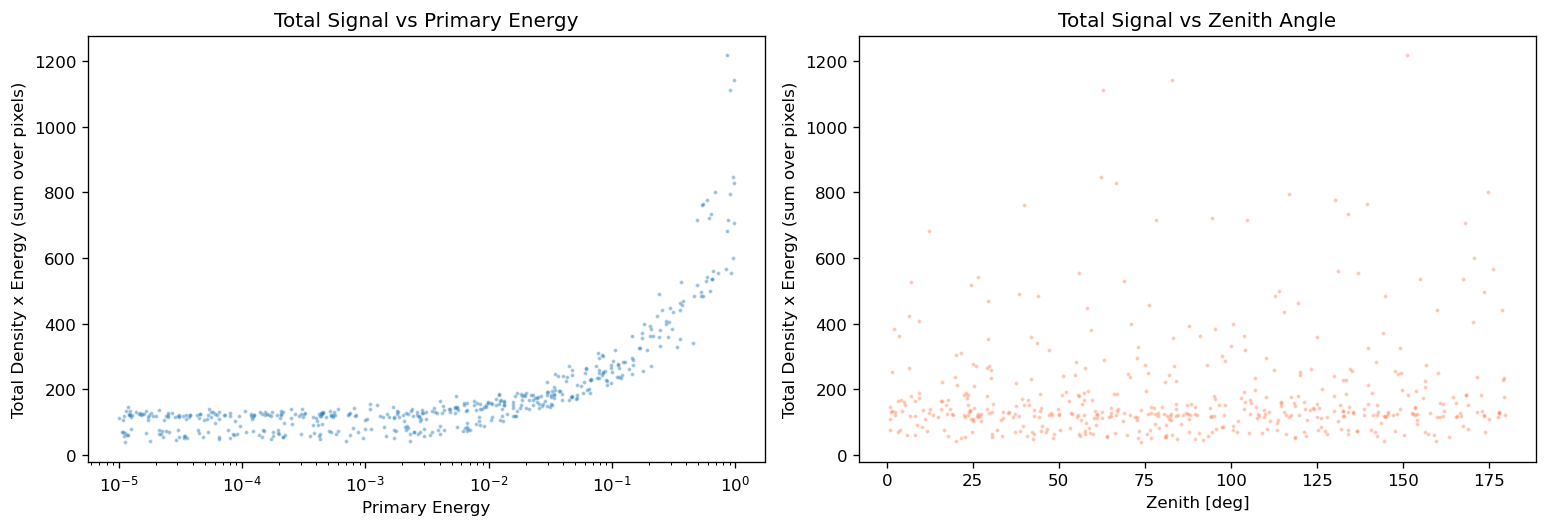

In [12]:
# Per-shower total signal (sum of density x energy over all pixels)
total_signal = density_energy.sum(dim=(1, 2))  # (N,)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Total signal vs energy
axes[0].scatter(p_energy.numpy(), total_signal.numpy(), s=2, alpha=0.3)
axes[0].set_xscale('log')
axes[0].set_xlabel('Primary Energy')
axes[0].set_ylabel('Total Density x Energy (sum over pixels)')
axes[0].set_title('Total Signal vs Primary Energy')

# Total signal vs zenith
axes[1].scatter(zenith_deg, total_signal.numpy(), s=2, alpha=0.3, color='coral')
axes[1].set_xlabel('Zenith [deg]')
axes[1].set_ylabel('Total Density x Energy (sum over pixels)')
axes[1].set_title('Total Signal vs Zenith Angle')

plt.tight_layout()
plt.show()